$$y^\delta = Ax + w \implies \min_{x \in \R^n} \|Ax-y^\delta\|^2_2 \implies A^TAx = A^Ty^\delta$$
Dove:
- $x$ è l'immagine
- $A$ è la funzione di convoluzione (con il kernel)
- $w$ è rumore
- $y^\delta$ è l'immagine sfocata

Risolvendo con la regola dei minimi quadrati, succede che l'immagine non riesce a trovare la soluzione, dato che cercando $y^\delta$ stiamo anche trovando il rumore, l'immagine comincia a trovare dei risultati assurdi.

Al posto di minimizzare $\min_{x \in \R^n} \|Ax-y^\delta\|^2_2$, lo faccio con un parametro $\lambda R(x)$, ovvero un "freno":

$$\min_{x \in \R^n} \|Ax-y^\delta\|^2_2+\lambda R(x), \quad \lambda > 0$$

$R(x) = $ Lx 

Quindi $\min \limits_{x_{\lambda} \in \R^n} \|Ax_\lambda-y^\delta\|^2_2 \approx 1.01 \|w\|^2_2$

La regolarizzazione di Tikhanov:
$$\min_{x \in \R^n} \|Ax-y^\delta\|^2_2+\lambda \|x\|^2_2 \implies (A^TA+\lambda I)x = A^Ty^\delta$$

## REGOLARIZZAZIONE CON VARIAZIONE TOTALE

Il difetto principale di Tikhonov è che odia i cambiamenti bruschi. Se c'è un bordo netto (es. la spalla scura del "Cameraman" contro il cielo chiaro), Tikhonov cerca di "addolcirlo" per ridurre l'energia. Risultato Tikhonov: Immagine senza rumore, ma sfocata sui bordi.

La Variazione Totale $TV(x)$ non guarda quanto sono grandi i valori dei pixel, ma somma i valori assoluti delle differenze tra pixel vicini.

$$TV(x)=||\nabla(x)||_1=\sum_{i=1}^M\sum_{j=1}^n \sqrt{(x_{i+1,j}-x_{i,j})^2+(x_{i,j+1}-x_{i,j})^2}$$

La funzione non è differenziabile nel punto $(0,0)$ (immagina la funzione come cono). Per ottenere la differenziabilità si pone $\beta>0$ e si scrive:

$$TV^{\beta}(x)=\sum_{i=1}^m\sum_{j=1}^n \sqrt{(x_{i+1,j}-x_{i,j})^2+(x_{i,j+1}-x_{i,j})^2+\beta^2}$$

Di solito $\beta$ è circa $10^{-3}$

Il problema di regolarizzazione diventa quindi:

$$min_x ||Ax-y^{\delta}||_2^2+\lambda TV^{\beta}(x)$$

È differenziabile e convessa, quindi **possiamo applicare il metodo del gradiente**

Guardati ER, PSNR, SSIM.
Il grafico con \lambda nelle x e ER nelle y, si ha un grafico convesso con \lambda* come minimo globale

## Import Librerie

In [2]:
from ProblemiInversi import operators, solvers, utilities
import numpy as np
from numpy.linalg import svd
import matplotlib.pyplot as plt
from skimage import data

## Compressione file con SVD

Dimensioni dell'immagine: 512 x 512
Rango massimo possibile: 512


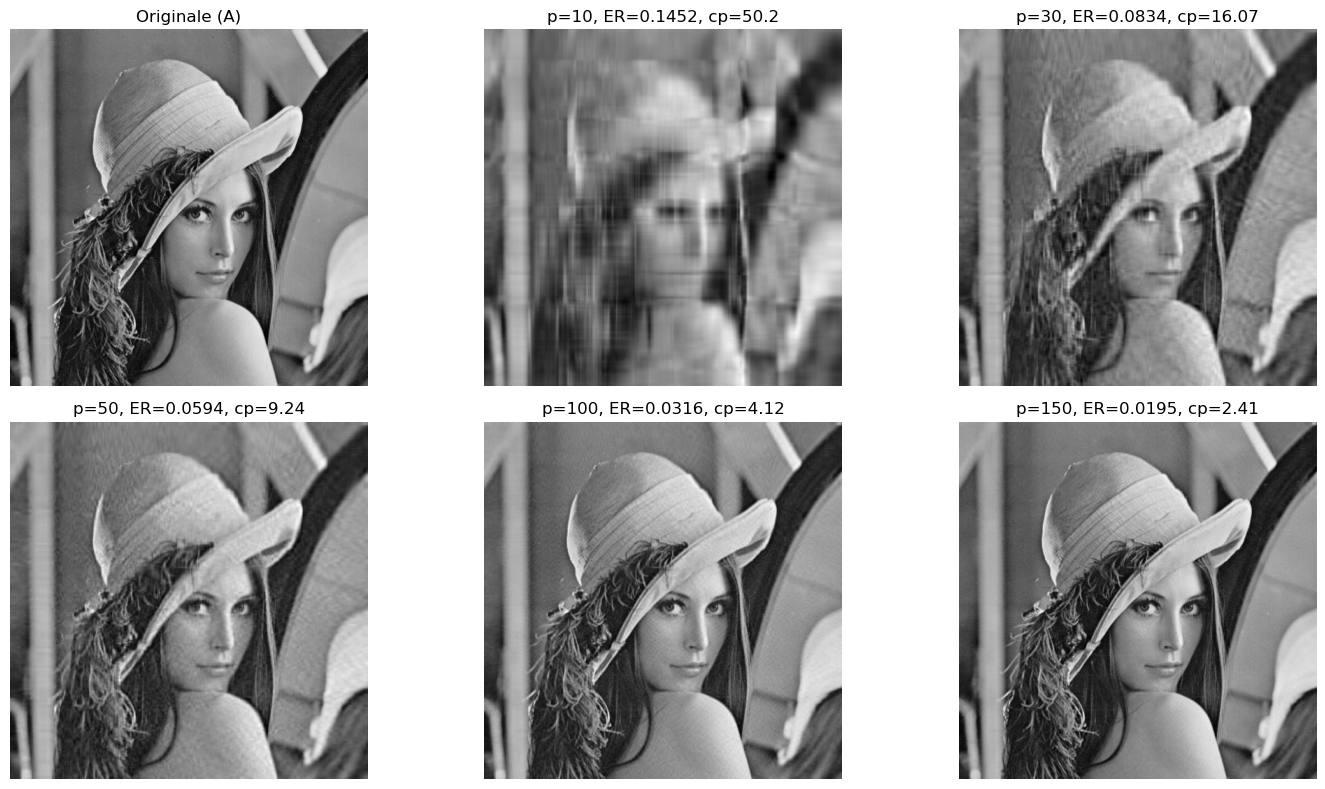

In [104]:
X=plt.imread("lena.bmp")

nx, ny = X.shape
rank=min(nx,ny)

print(f"Dimensioni dell'immagine: {nx} x {ny}")
print(f"Rango massimo possibile: {rank}")

U, s, Vt = svd(X, full_matrices=False)

p_arr = [10, 30, 50, 100, 150]
errors = []
reconstructions = []
compressions = []

norm_A = np.linalg.norm(X)

for i in p_arr:
    # --- Calcolo della matrice A_p ---
    S_p = np.diag(s[:i])
    A_p = U[:, :i] @ S_p @ Vt[:i, :]
    reconstructions.append(A_p)
    
    # --- Calcolo dell'errore relativo in norma 2 ---
    diff_norm = np.linalg.norm(X - A_p)
    rel_error = diff_norm / norm_A
    errors.append(rel_error)

    cp = (1/i) * rank - 1
    compressions.append(cp)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(X, cmap='gray')
plt.title("Originale (A)")
plt.axis('off')

# Mostra le ricostruzioni per i vari p
for i, p in enumerate(p_arr):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructions[i], cmap='gray')
    plt.title(f"p={p}, ER={np.round(errors[i],4)}, cp={np.round(compressions[i],2)}")
    plt.axis('off')

plt.tight_layout()
plt.show()

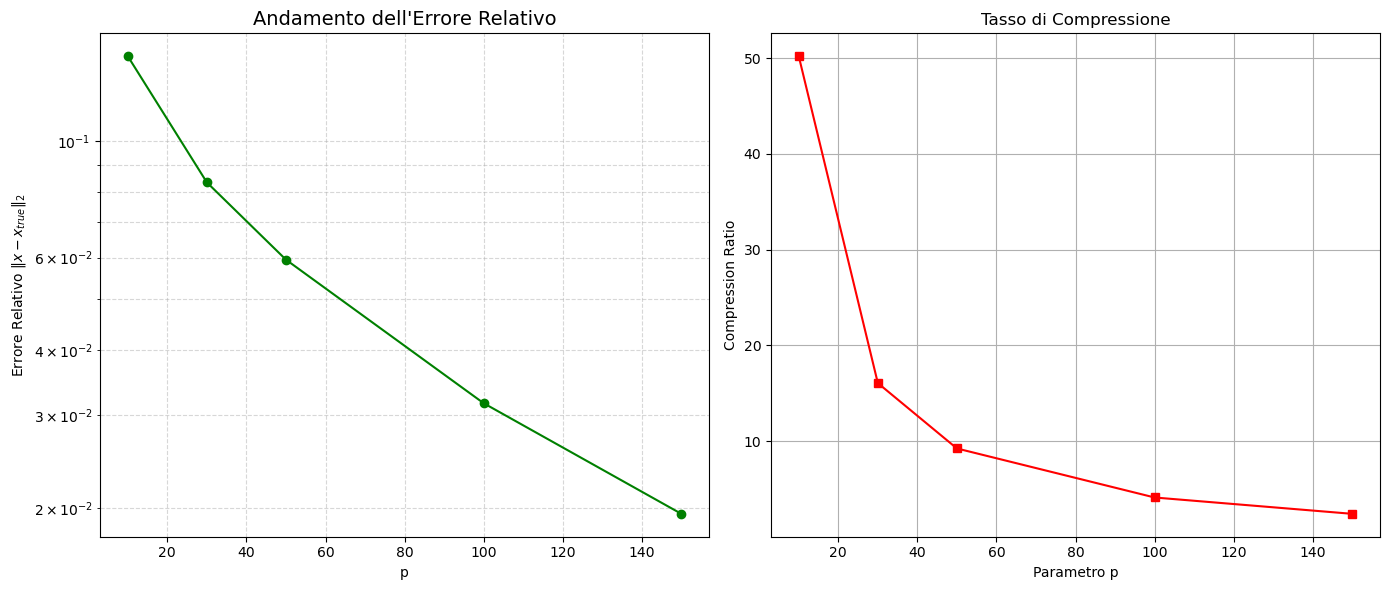

In [105]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.semilogy(p_arr, errors, color='green', marker='o', linestyle='-', label='Errore Relativo')
plt.title("Andamento dell'Errore Relativo", fontsize=14)
plt.xlabel("p")
plt.ylabel(r"Errore Relativo $\|x - x_{true}\|_2$")
plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(p_arr, compressions, color='red', marker='s', linestyle='-', label='Compression Ratio')
plt.title("Tasso di Compressione")
plt.xlabel("Parametro p")
plt.ylabel("Compression Ratio")
plt.grid(True)

plt.tight_layout()
plt.show()

## Sfocamento

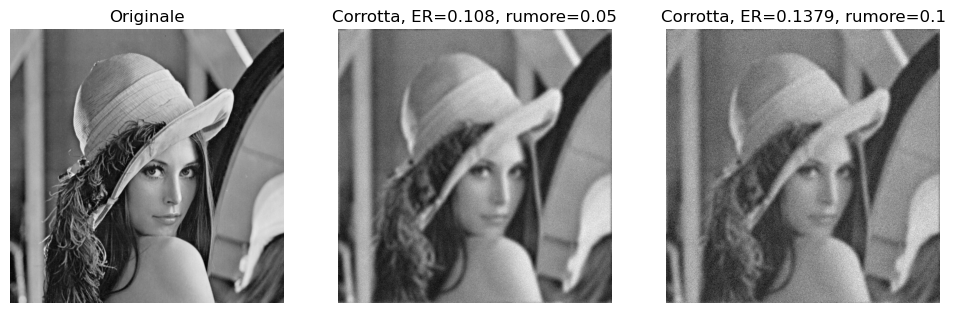

In [106]:
# Definizione kernel di blur e operatore associato
kernel = utilities.gaussian2d_kernel(k=11, sigma=3.5)
A = operators.ConvolutionOperator(kernel)

# Sfocatura dell'immagine
y = A(X)

noise_level1 = 0.05
noise_level2 = 0.1

# Aggiunta rumore
y_delta1 = y + utilities.gaussian_noise(y, noise_level=noise_level1)
y_delta2 = y + utilities.gaussian_noise(y, noise_level=noise_level2)

ER_sfocatura1 = utilities.rel_err(y_delta1, X)
ER_sfocatura1 = np.round(ER_sfocatura1, 4)

ER_sfocatura2 = utilities.rel_err(y_delta2, X)
ER_sfocatura2 = np.round(ER_sfocatura2, 4)

# Show della sfocatura
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(X, cmap="gray")
plt.axis("off")
plt.title("Originale")

plt.subplot(1, 3, 2)
plt.imshow(y_delta1, cmap="gray")
plt.axis("off")
plt.title(f"Corrotta, ER={ER_sfocatura1}, rumore={noise_level1}")

plt.subplot(1, 3, 3)
plt.imshow(y_delta2, cmap="gray")
plt.axis("off")
plt.title(f"Corrotta, ER={ER_sfocatura2}, rumore={noise_level2}")
plt.show()

## Ricostruzione Naive CGLS

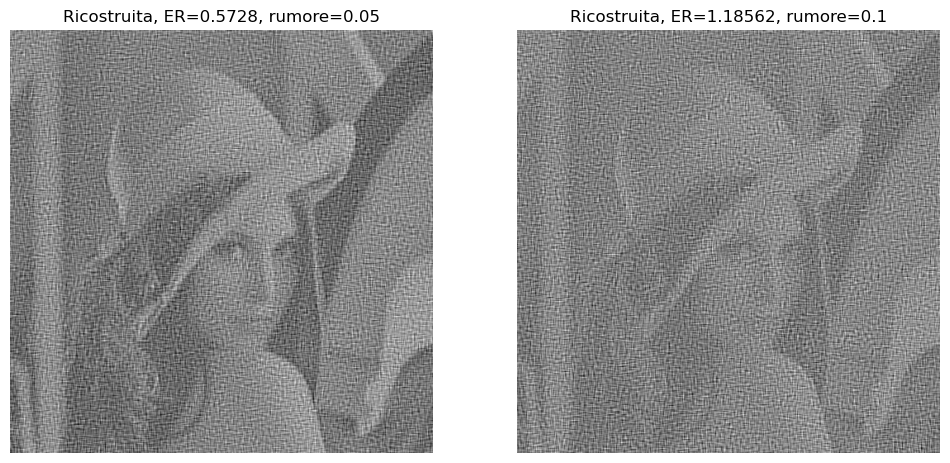

In [107]:
cgls_solver = solvers.CGLS(A)

x0 = np.zeros_like(X)
kmax = 30
tolf = 1e-8
tolx = 1e-8

x_cgls1 = cgls_solver.solve(y_delta1, x0, kmax, tolf, tolx)
x_cgls2 = cgls_solver.solve(y_delta2, x0, kmax, tolf, tolx)

ER_naive1=np.round(utilities.rel_err(x_cgls1, X), 5)
ER_naive2=np.round(utilities.rel_err(x_cgls2, X), 5)

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(x_cgls1, cmap="gray")
plt.axis("off")
plt.title(f"Ricostruita, ER={ER_naive1}, rumore={noise_level1}")

plt.subplot(1,2,2)
plt.imshow(x_cgls2, cmap="gray")
plt.axis("off")
plt.title(f"Ricostruita, ER={ER_naive2}, rumore={noise_level2}")

plt.show()

## Ricostruzione Tikhonov

In [108]:
def Tikhonov(A, y, lamb, y_delta, X):
    L = operators.Identity()
    M = operators.TikhonovOperator(A, L, lamb)

    ybar_delta = np.pad(y_delta, ((0, nx), (0, 0)))

    cgls_tik_solver = solvers.CGLS(M)
    x_tik = cgls_tik_solver.solve(ybar_delta, x0, kmax, tolf, tolx)

    abs_err = np.linalg.norm(x_tik - X)
    
    residual_vector = A(x_tik) - y_delta 
    res_val = np.linalg.norm(residual_vector)

    return x_tik, abs_err, res_val

In [102]:
lambdas = np.logspace(-5, 1, 20)

results1 = []
results2 = []

y = A(X)

for i in lambdas:
    results1.append(Tikhonov(A, y, i, y_delta1, X))
    results2.append(Tikhonov(A, y, i, y_delta2, X))

solutions1, errors_er1, residuals1 = zip(*results1)
solutions2, errors_er2, residuals2 = zip(*results2)

# print('ER',utilities.rel_err(x_tik, X))
# print('PSNR',utilities.psnr(x_tik, X))
# print('SSIM',utilities.ssim(x_tik, X))

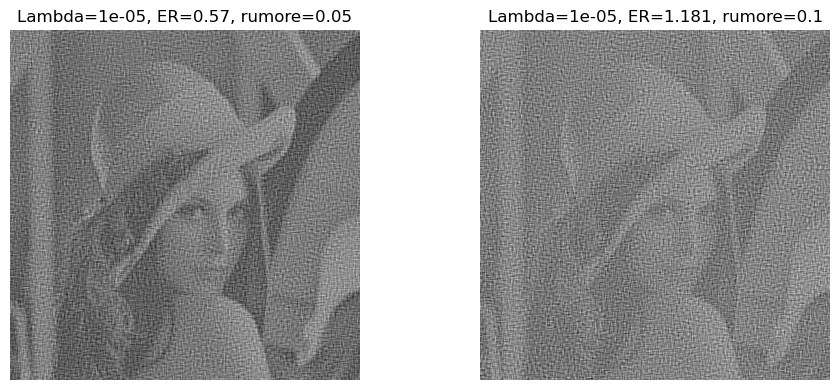

In [109]:
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.imshow(solutions1[0], cmap="gray")
plt.axis("off")
e = np.round(utilities.rel_err(solutions1[0], X), 3)
plt.title(f"Lambda={lambdas[0]}, ER={e}, rumore={noise_level1}")

plt.subplot(1,2,2)
plt.imshow(solutions2[0], cmap="gray")
plt.axis("off")
e = np.round(utilities.rel_err(solutions2[0], X), 3)
plt.title(f"Lambda={lambdas[0]}, ER={e}, rumore={noise_level2}")

plt.tight_layout()
plt.show()

In [110]:
def graph_error(abs_error, solutions, residuals, noise_level, noise_norm):
    idx_min_err = np.argmin(abs_error)
    best_lambda_err = lambdas[idx_min_err]
    x_best_err = solutions[idx_min_err]
    min_error_val = abs_error[idx_min_err]

    print(f"\nLambda (Minimo Errore): {best_lambda_err:.2e}")
    print(f"Errore minimo: {min_error_val:.4f}")

    idx_discrepancy = np.argmin(np.abs(np.array(residuals) - noise_norm))
    best_lambda_discrepancy = lambdas[idx_discrepancy]
    x_best_disc = solutions[idx_discrepancy]

    print(f"Lambda (Discrepanza): {best_lambda_discrepancy:.2e}")
    print(f"Residuo al lambda discrepanza: {residuals[idx_discrepancy]:.4f}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.loglog(lambdas, abs_error, 'b-o', label=r'Errore Assoluto')
    plt.axvline(x=best_lambda_err, color='r', linestyle='--', label=rf'Errore Minimo ($\lambda$={best_lambda_err:.1e})')
    plt.xlabel('Lambda')
    plt.ylabel('Errore di Ricostruzione')
    plt.title(f'Minimizzazione Errore, rumore={noise_level}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.4)

    plt.subplot(1, 2, 2)
    plt.loglog(lambdas, residuals, 'g-o', label=r'Residuo $\|Ax - y_\delta\|$')
    plt.axhline(y=noise_norm, color='k', linestyle='--', label=r'Livello Rumore ($\delta$)')
    plt.axvline(x=best_lambda_discrepancy, color='m', linestyle='--', label=rf'Discrepanza ($\lambda$={best_lambda_discrepancy:.1e})')
    plt.xlabel('Lambda')
    plt.ylabel('Norma del Residuo')
    plt.title(f'Principio Discrepanza, rumore={noise_level}')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.4)

    plt.tight_layout()
    plt.show()


Lambda (Minimo Errore): 1.27e-01
Errore minimo: 6100.4331
Lambda (Discrepanza): 1.27e-01
Residuo al lambda discrepanza: 3452.9885


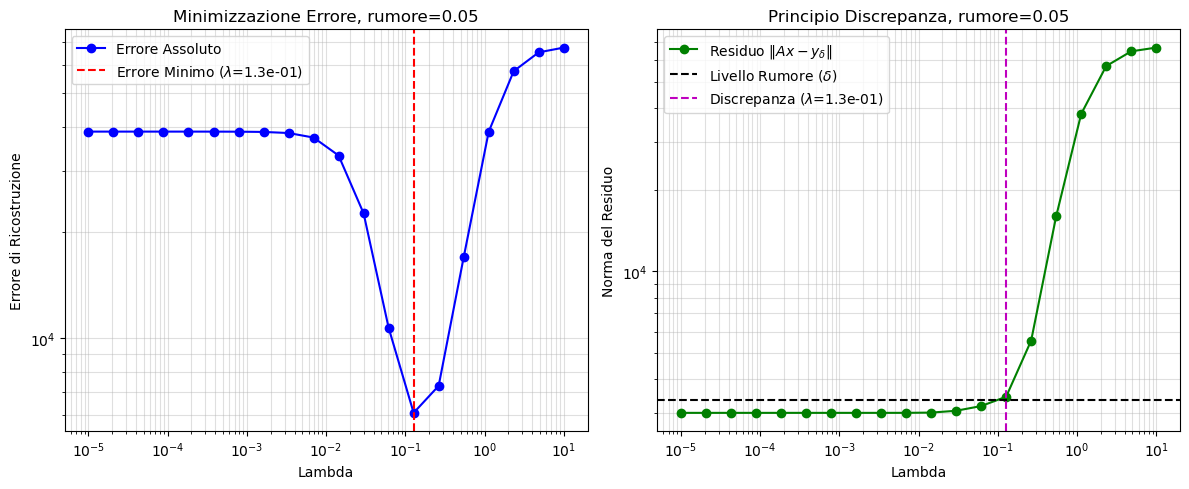


Lambda (Minimo Errore): 2.64e-01
Errore minimo: 7586.6125
Lambda (Discrepanza): 1.27e-01
Residuo al lambda discrepanza: 6628.4482


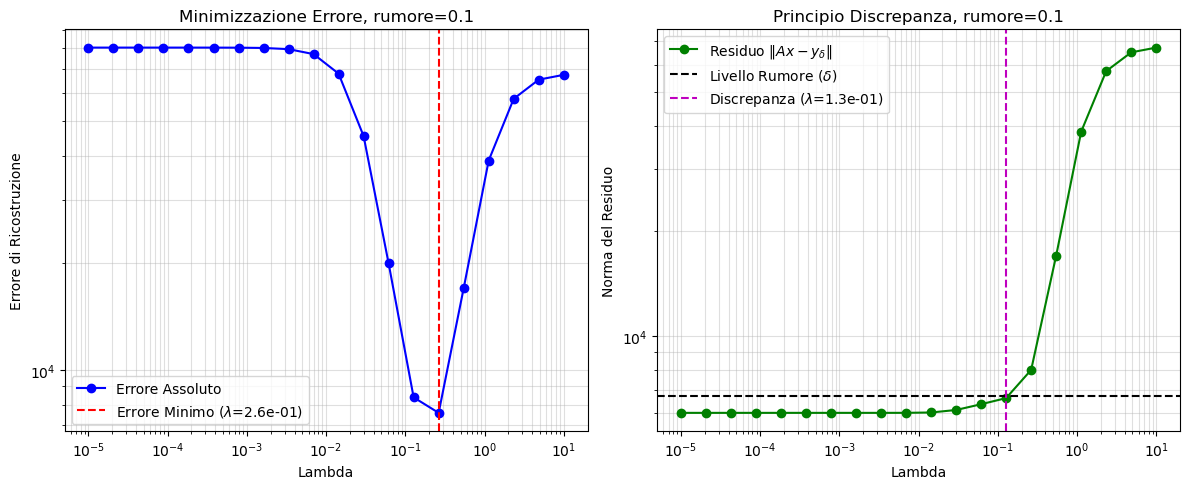

In [111]:
noise_norm1 = np.linalg.norm(y_delta1 - y)
noise_norm2 = np.linalg.norm(y_delta2 - y)
graph_error(errors_er1, solutions1, residuals1, noise_level1, noise_norm1)
graph_error(errors_er2, solutions2, residuals2, noise_level2, noise_norm2)

---
## Ricostruzione Con Total Variation

Avvio scansione su 20 valori di lambda per TV...

Miglior Lambda TV: 2.34e-01
Errore Minimo TV: 5624.8188


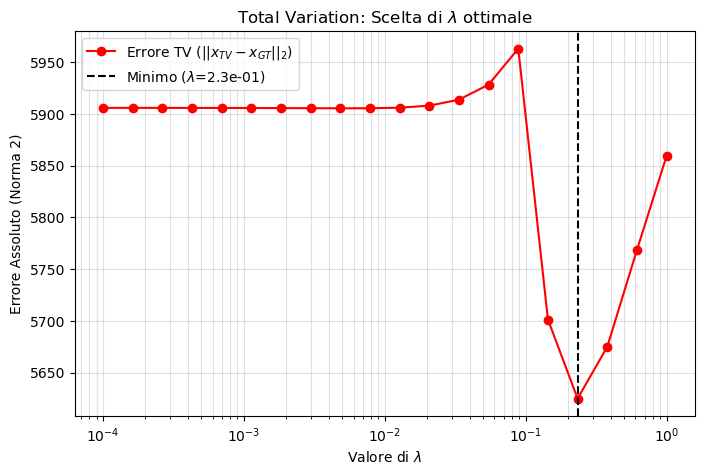

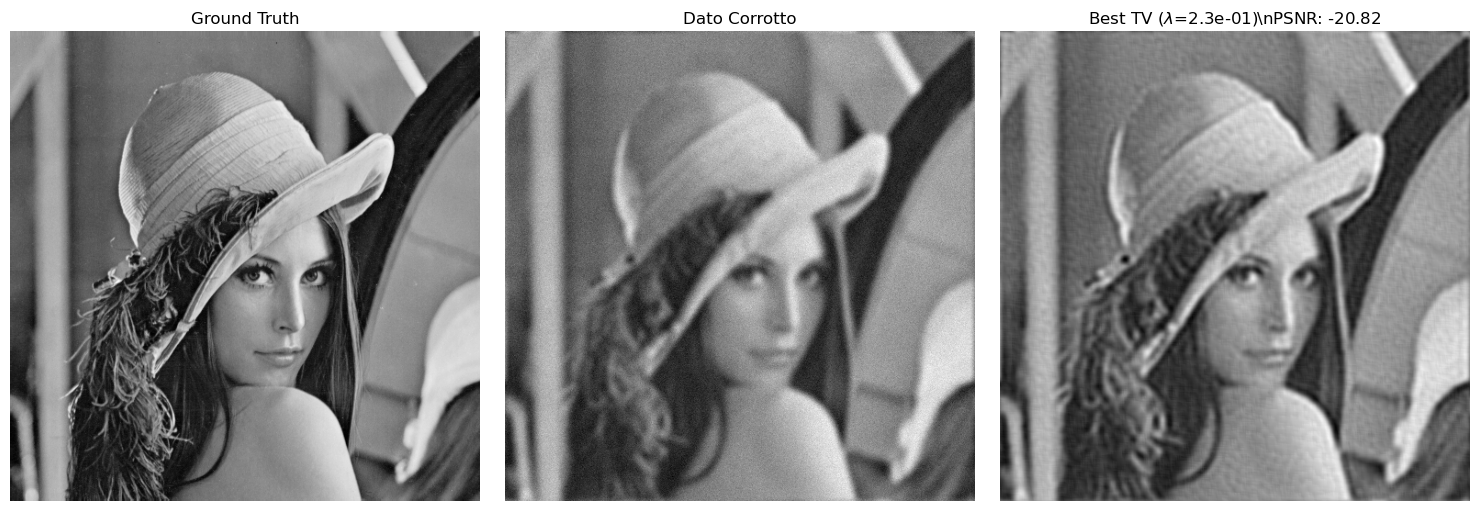

------------------------------
PSNR TV Ottimale: -20.82 dB
SSIM TV Ottimale: -20.82


In [ ]:
lambdas_tv = np.logspace(-4, 0, 20) 

errors_tv = []
solutions_tv = []

beta = 1e-3
gd_tv_solver = solvers.GDTotalVariation(A, beta=beta)

x0 = np.zeros_like(A)
kmax = 50
tolf = 1e-8
tolx = 1e-8

print(f"Avvio scansione su {len(lambdas_tv)} valori di lambda per TV...")

# --- 2. Ciclo di Ottimizzazione ---
for lmbda in lambdas_tv:
    # Il metodo solve prende lambda come argomento
    # x_TV, obj_val, grad_norm = ...
    val, _, _ = gd_tv_solver.solve(y_delta1, lmbda, x0, kmax, tolf, tolx)
    
    # Calcolo errore rispetto al Ground Truth
    err = np.linalg.norm(val - A)
    
    errors_tv.append(err)
    solutions_tv.append(val)

# --- 3. Selezione del Miglior Lambda (Minimo Errore) ---
errors_tv = np.array(errors_tv)
idx_min_tv = np.argmin(errors_tv)

best_lambda_tv = lambdas_tv[idx_min_tv]
x_best_tv = solutions_tv[idx_min_tv]
min_err_tv = errors_tv[idx_min_tv]

print(f"\nMiglior Lambda TV: {best_lambda_tv:.2e}")
print(f"Errore Minimo TV: {min_err_tv:.4f}")

# --- 4. Visualizzazione Grafico Errore vs Lambda ---
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas_tv, errors_tv, 'r-o', label=r'Errore TV ($||x_{TV} - x_{GT}||_2$)')
plt.axvline(x=best_lambda_tv, color='k', linestyle='--', label=fr'Minimo ($\lambda$={best_lambda_tv:.1e})')
plt.xlabel(r'Valore di $\lambda$')
plt.ylabel('Errore Assoluto (Norma 2)')
plt.title(r'Total Variation: Scelta di $\lambda$ ottimale')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()

# --- 5. Visualizzazione Immagini Finali ---
plt.figure(figsize=(15, 5))

# Ground Truth
plt.subplot(1, 3, 1)
plt.imshow(A, cmap="gray")
plt.axis("off")
plt.title("Ground Truth")

# Corrotta
plt.subplot(1, 3, 2)
plt.imshow(y_delta1, cmap="gray")
plt.axis("off")
plt.title("Dato Corrotto")

# Miglior Ricostruzione TV
plt.subplot(1, 3, 3)
plt.imshow(x_best_tv, cmap="gray")
plt.axis("off")
plt.title(fr"Best TV ($\lambda$={best_lambda_tv:.1e}) PSNR: {utilities.psnr(x_best_tv, A):.2f}")

plt.tight_layout()
plt.show()

# --- 6. Metriche ---
print("-" * 30)
print(f"PSNR TV Ottimale: {utilities.psnr(x_best_tv, A):.2f} dB")
print(f"SSIM TV Ottimale: {utilities.psnr(x_best_tv, A):.2f}") # Nota: verifica se utilities ha ssim o usa skimage